# Black-Litterman allocation

The Black-Litterman method is a very powerful way of converting your views on asset returns, along with your uncertainty in these views, into a portfolio.

For a description of the theory, please read the [documentation page](https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html) and the links therein.

In this recipe, we will cover:

- Downloading data for the Black-Litterman method
- Constructing the prior return vector based on market equilibrium
- Two ways of constructing the uncertainty matrix
- Combining Black-Litterman with mean-variance optimization

## Downloading data

In addition to price data, constructing a market prior requires market-caps.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/PyPortfolio/PyPortfolioOpt/blob/main/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)

In [29]:
!pip install pandas numpy matplotlib PyPortfolioOpt
import os
if not os.path.isdir('data'):
    os.system('git clone https://github.com/pyportfolio/pyportfolioopt.git')
    os.chdir('PyPortfolioOpt/cookbook')


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt.data.data_loader import load_stockdata, load_marketcaps

In [31]:
tickers = ["MSFT", "AMZN", "NAT", "BAC", "DPZ", "DIS", "KO", "MCD", "COST", "SBUX"]

In [32]:
prices = load_stockdata(tickers=tickers)
prices

,MSFT,AMZN,NAT,BAC,DPZ,DIS,KO,MCD,COST,SBUX
date,,,,,,,,,,
2023-01-03,233.452805,85.820000,2.239412,30.974270,324.958191,86.923027,57.519150,246.610382,435.046295,93.157562
2023-01-04,223.240845,85.139999,2.179293,31.556591,329.862274,89.863770,57.491734,246.666412,438.194336,96.511368
2023-01-05,216.624481,83.120003,2.194323,31.491892,324.536804,89.805138,56.833855,244.585876,432.080658,96.483658
2023-01-06,219.177475,86.080002,2.216867,31.806164,328.166931,91.759132,57.930328,251.405792,463.446045,98.571686
2023-01-09,221.311462,87.360001,2.194323,31.325518,319.795624,92.589569,57.208481,249.334641,459.491791,96.770058
...,...,...,...,...,...,...,...,...,...,...
2026-02-24,389.000000,208.559998,5.000000,50.410000,414.200012,106.050003,80.720001,333.049988,998.429993,96.510002
2026-02-25,400.600006,210.639999,5.040000,51.689999,403.940002,105.050003,80.470001,333.010010,994.760010,97.930000
2026-02-26,401.720001,207.919998,5.400000,52.299999,399.290009,105.550003,80.500000,334.529999,986.739990,98.080002


In [33]:
market_prices = load_stockdata(tickers=["SPY"])
market_prices.head()

,SPY
date,
2023-01-03,366.069153
2023-01-04,368.895233
2023-01-05,364.684845
2023-01-06,373.047852
2023-01-09,372.836395


In [34]:
mcaps = load_marketcaps(tickers=tickers)
mcaps

{'AMZN': 2237050126336,
 'BAC': 363737317376,
 'COST': 445187457024,
 'DIS': 185017466880,
 'DPZ': 13497629696,
 'KO': 345075089408,
 'MCD': 238929035264,
 'MSFT': 2962173984768,
 'NAT': 1262033920,
 'SBUX': 110238670848}

## Constructing the prior

In [35]:
import pypfopt
pypfopt.__version__

'1.6.0'

In [36]:
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, plotting

S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
delta = black_litterman.market_implied_risk_aversion(market_prices)
delta

np.float64(9.191168760009134)

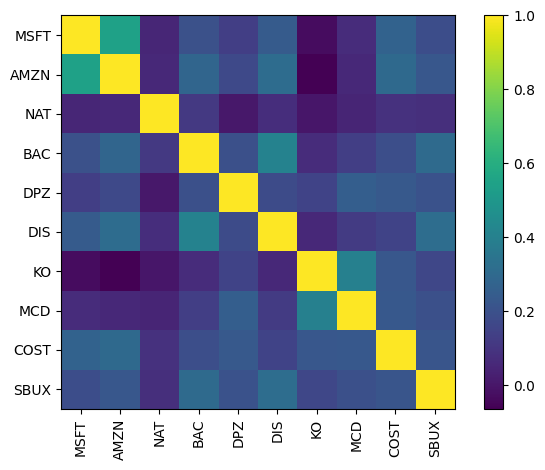

In [37]:
plotting.plot_covariance(S, plot_correlation=True);

In [38]:
market_prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)
market_prior

MSFT    0.379277
AMZN    0.495600
NAT     0.050252
BAC     0.169859
DPZ     0.109646
DIS     0.190336
KO      0.008740
MCD     0.047517
COST    0.151156
SBUX    0.173110
dtype: float64

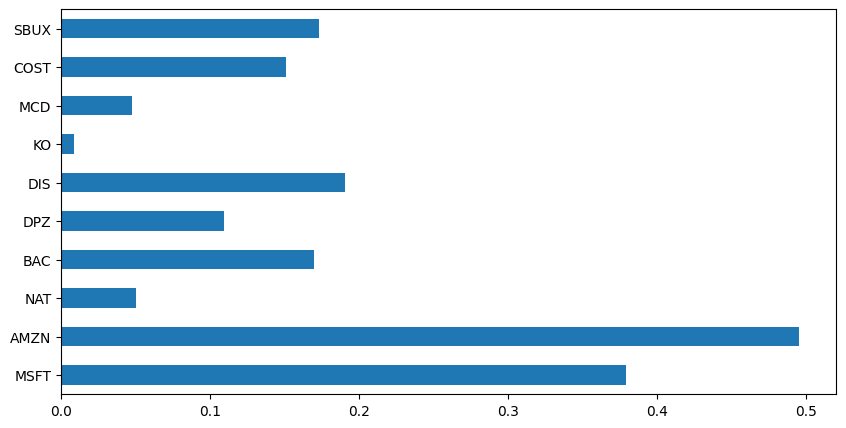

In [39]:
market_prior.plot.barh(figsize=(10,5));

## Views

In the BL method, views are specified via the matrix P (picking matrix) and the vector Q. Q contains the magnitude of each view, while P maps the views to the assets they belong to. 

If you are providing **absolute views** (i.e a return estimate for each asset), you don't have to worry about P and Q, you can just pass your views as a dictionary.

In [40]:
# You don't have to provide views on all the assets
viewdict = {
    "AMZN": 0.10,
    "BAC": 0.30,
    "COST": 0.05,
    "DIS": 0.05,
    "DPZ": 0.20,
    "KO": -0.05,  # I think Coca-Cola will go down 5%
    "MCD": 0.15,
    "MSFT": 0.10,
    "NAT": 0.50,  # but low confidence, which will be reflected later
    "SBUX": 0.10
}

bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict)

Black-Litterman also allows for relative views, e.g you think asset A will outperform asset B by 10%. If you'd like to incorporate these, you will have to build P and Q yourself. An explanation for this is given in the [docs](https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html#views).

## View confidences

In this section, we provide two ways that you may wish to construct the uncertainty matrix. The first is known as Idzorek's method. It allows you to specify a vector/list of percentage confidences.

In [41]:
confidences = [
    0.6,
    0.4,
    0.2,
    0.5,
    0.7, # confident in dominos
    0.7, # confident KO will do poorly
    0.7, 
    0.5,
    0.1,
    0.4
]

In [42]:
bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict, omega="idzorek", view_confidences=confidences)

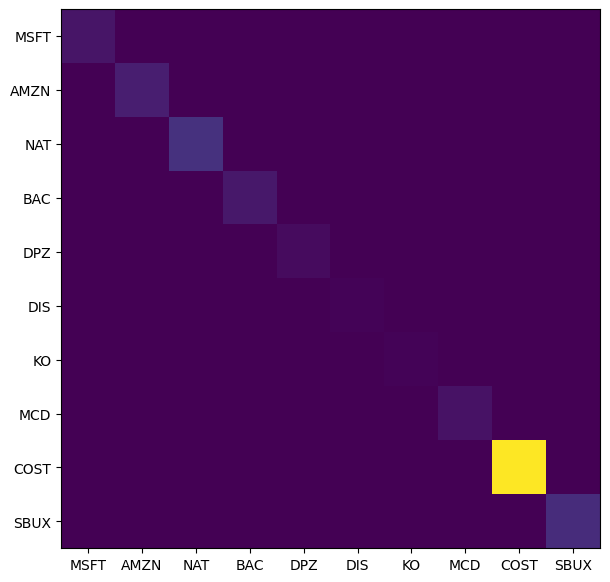

In [43]:
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(bl.omega)

# We want to show all ticks...
ax.set_xticks(np.arange(len(bl.tickers)))
ax.set_yticks(np.arange(len(bl.tickers)))

ax.set_xticklabels(bl.tickers)
ax.set_yticklabels(bl.tickers)
plt.show()

In [44]:
np.diag(bl.omega)

array([0.00332932, 0.00494865, 0.00839191, 0.00382193, 0.00167528,
       0.00054176, 0.00066118, 0.00295894, 0.05913867, 0.00745779])

Note how NAT, which we gave the lowest confidence, also has the highest uncertainty.

Instead of inputting confidences, we can calculate the uncertainty matrix directly by specifying 1 standard deviation confidence intervals, i.e bounds which we think will contain the true return 68% of the time. This may be easier than coming up with somewhat arbitrary percentage confidences

In [45]:
intervals = [
    (0, 0.25),
    (0.1, 0.4),
    (-0.1, 0.15),
    (-0.05, 0.1),
    (0.15, 0.25),
    (-0.1, 0),
    (0.1, 0.2),
    (0.08, 0.12),
    (0.1, 0.9),
    (0, 0.3)
]

In [46]:
variances = []
for lb, ub in intervals:
    sigma = (ub - lb)/2
    variances.append(sigma ** 2)

print(variances)
omega = np.diag(variances)

[0.015625, 0.022500000000000006, 0.015625, 0.0056250000000000015, 0.0025000000000000005, 0.0025000000000000005, 0.0025000000000000005, 0.00039999999999999986, 0.16000000000000003, 0.0225]


## Posterior estimates

Given the inputs, we can compute a posterior estimate of returns


In [47]:
# We are using the shortcut to automatically compute market-implied prior
bl = BlackLittermanModel(S, pi="market", market_caps=mcaps, risk_aversion=delta,
                        absolute_views=viewdict, omega=omega)

In [48]:
# Posterior estimate of returns
ret_bl = bl.bl_returns()
ret_bl

MSFT    0.131388
AMZN    0.287238
NAT     0.051403
BAC     0.136114
DPZ     0.150090
DIS     0.103109
KO      0.007524
MCD     0.076836
COST    0.096954
SBUX    0.118682
dtype: float64

We can visualise how this compares to the prior and our views:

In [49]:
rets_df = pd.DataFrame([market_prior, ret_bl, pd.Series(viewdict)], 
             index=["Prior", "Posterior", "Views"]).T
rets_df

,Prior,Posterior,Views
MSFT,0.379277,0.131388,0.10
AMZN,0.495600,0.287238,0.10
NAT,0.050252,0.051403,0.50
BAC,0.169859,0.136114,0.30
DPZ,0.109646,0.150090,0.20
DIS,0.190336,0.103109,0.05
KO,0.008740,0.007524,-0.05
MCD,0.047517,0.076836,0.15
COST,0.151156,0.096954,0.05
SBUX,0.173110,0.118682,0.10


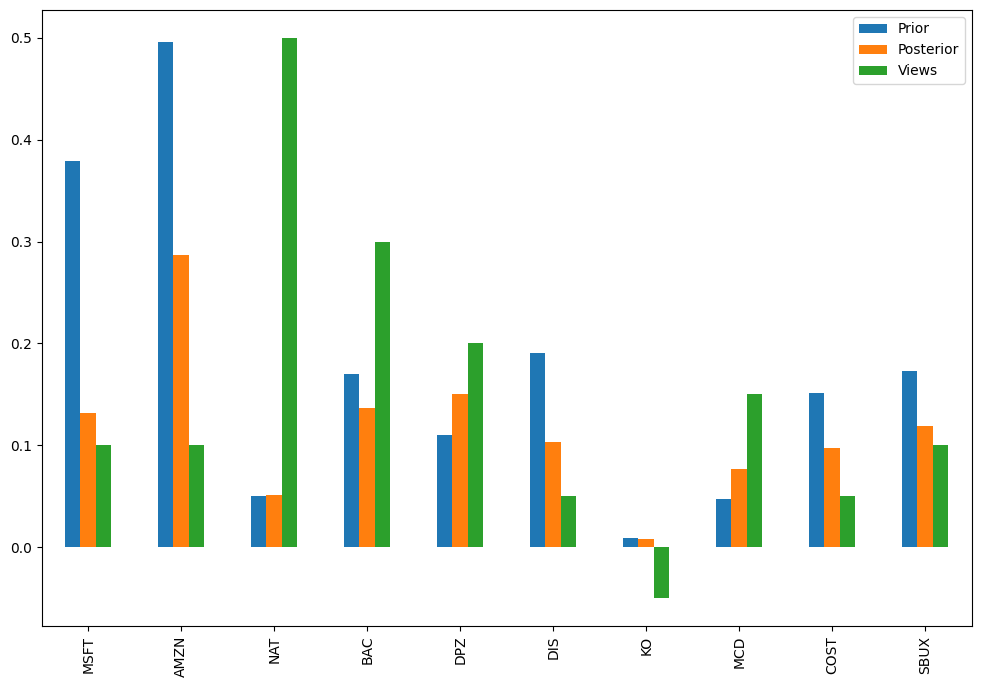

In [50]:
rets_df.plot.bar(figsize=(12,8));

Notice that the posterior is often between the prior and the views. This supports the fact that the BL method is essentially a Bayesian weighted-average of the prior and views, where the weight is determined by the confidence.

A similar but less intuitive procedure can be used to produce the posterior covariance estimate:

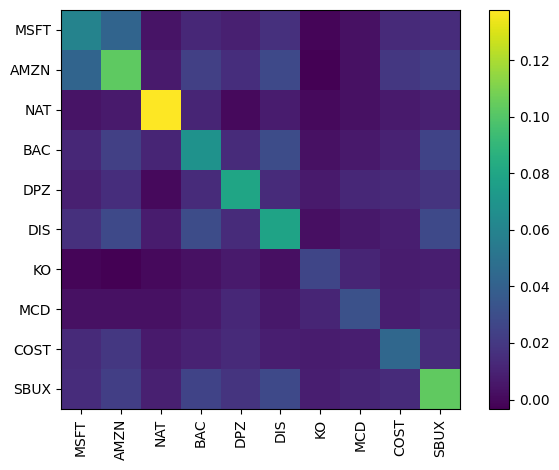

In [51]:
S_bl = bl.bl_cov()
plotting.plot_covariance(S_bl);

## Portfolio allocation

Now that we have constructed our Black-Litterman posterior estimate, we can proceed to use any of the optimizers discussed in previous recipes.

In [52]:
from pypfopt import EfficientFrontier, objective_functions

In [53]:
ef = EfficientFrontier(ret_bl, S_bl)
ef.add_objective(objective_functions.L2_reg)
ef.max_sharpe()
weights = ef.clean_weights()
weights

C:\Users\shuvam\sparkle\pyportfolio\pypfopt\efficient_frontier\efficient_frontier.py:281: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


OrderedDict([('MSFT', 0.1121),
             ('AMZN', 0.25596),
             ('NAT', 0.04179),
             ('BAC', 0.11741),
             ('DPZ', 0.13371),
             ('DIS', 0.08225),
             ('KO', 0.00497),
             ('MCD', 0.07151),
             ('COST', 0.08448),
             ('SBUX', 0.09581)])

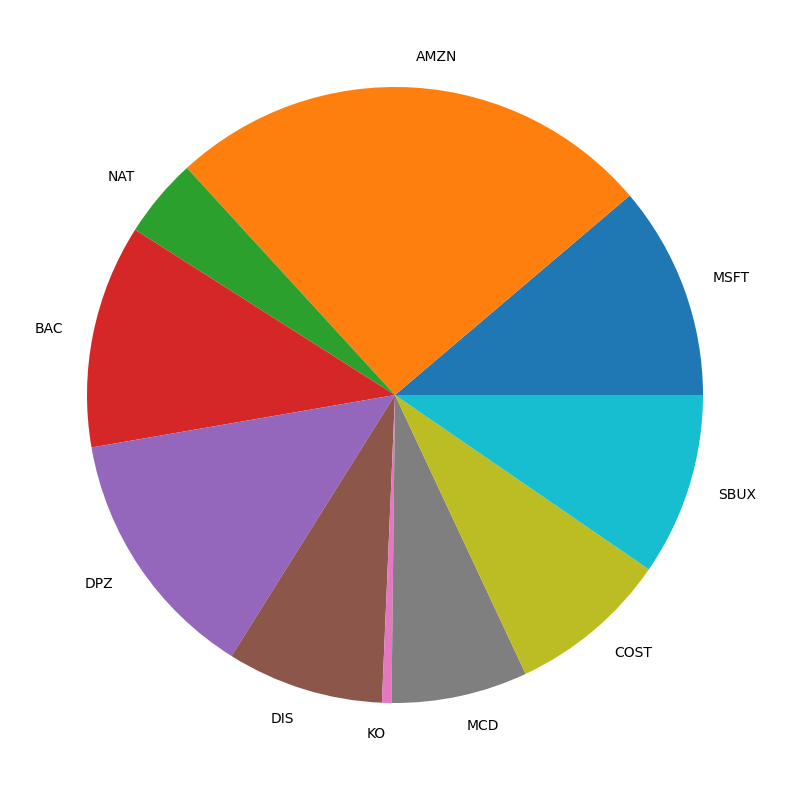

In [54]:
pd.Series(weights).plot.pie(figsize=(10,10));

In [55]:
from pypfopt import DiscreteAllocation

da = DiscreteAllocation(weights, prices.iloc[-1], total_portfolio_value=20000)
alloc, leftover = da.lp_portfolio()
print(f"Leftover: ${leftover:.2f}")
alloc

Leftover: $3.23


{'MSFT': 5,
 'AMZN': 24,
 'NAT': 138,
 'BAC': 47,
 'DPZ': 7,
 'DIS': 16,
 'KO': 1,
 'MCD': 4,
 'COST': 2,
 'SBUX': 20}